## Setup — Mount Drive & Load Parquet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.options.mode.string_storage = 'pyarrow'

SAVEDIR = '/content/drive/MyDrive/dblp-ref/'

DATASET = SAVEDIR + 'dblp_preprocessed.parquet'
TFIDF_MATRIX = SAVEDIR + 'tfidf_matrix.pkl'
TFIDF_VECTORIZER = SAVEDIR + 'tfidf_vectorizer.pkl'

combined_df = pd.read_parquet(DATASET)
X_tfidf = joblib.load(TFIDF_MATRIX)
V_tfidf = joblib.load(TFIDF_VECTORIZER)

print(f'Loaded: {combined_df.shape[0]:,} rows × {combined_df.shape[1]} columns')
display(combined_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 3,079,007 rows × 30 columns


,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,references_0,references_1,references_2,references_3,references_4,references_5,references_6,references_7,references_8,references_9,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",-0.223340,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,0.669529,00127ee2-cb05-48ce-bc49-9de556b93346,preliminary design of a network protocol learn...,2.764640,0.126227,0.258858,0.212288,-0.426914,0.100952,0.027788,-0.236404,0.240448,0.292128,-0.087653,-0.267190,-0.305477,-0.136099,-0.090603,0.082991,-0.316415,-0.293604,0.112798,-0.413274,0.081158
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",0.093716,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,0.413662,001c58d3-26ad-46b3-ab3a-c1e557d16821,a methodology for the physically accurate visu...,-0.605276,0.620194,0.301490,-0.065040,0.063580,-0.768892,-0.390491,-0.317761,-0.297342,0.377748,-0.368097,0.893701,-0.472392,0.589560,-0.673034,-0.610204,-0.471977,-0.172192,-0.003315,-0.867900,-0.438335
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",0.093716,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,0.157794,001c8744-73c4-4b04-9364-22d31a10dbf1,comparison of garch neural network and support...,0.518029,0.443020,0.161092,-0.017975,0.028602,-0.192726,0.127006,-0.489281,-0.580091,0.655932,-0.451510,-0.454386,-0.210310,-0.160133,0.212752,-0.137549,-0.134914,-0.313803,0.213007,0.046193,0.265358
3,,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",-0.223340,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,0.413662,00338203-9eb3-40c5-9f31-cbac73a519ec,development of remote monitoring and control d...,1.079682,0.043231,0.587941,0.329221,-0.166813,0.007523,0.323627,-0.107209,0.173355,-0.003126,-0.685121,-0.527497,0.438907,-0.479178,-0.475394,-0.597755,-1.017956,-0.227117,0.541668,0.315353,0.213414
4,,"[Giovanna Guerrini, Isabella Merlo]",-0.210658,[],Reasonig about Set-Oriented Methods in Object ...,,-1.249479,0040b022-1472-4f70-a753-74832df65266,reasonig about set oriented methods in object ...,-0.605276,0.843560,0.607843,0.264429,-0.170894,-0.354336,0.310527,-0.717752,-0.745651,0.644501,-0.499486,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079


## List author count

In [ ]:
print('n_authors column summary:')
print(combined_df['n_authors'].describe())
display(combined_df['n_authors'].value_counts().head(10))

n_authors column summary:
count    3.079007e+06
mean     1.417851e-17
std      1.000000e+00
min     -1.728581e+00
25%     -6.052757e-01
50%     -4.362310e-02
75%      5.180295e-01
max      1.954115e+02
Name: n_authors, dtype: float64


,count
n_authors,
-0.605276,901139
-0.043623,834656
0.518029,505744
-1.166928,384330
1.079682,240360
1.641335,108555
2.202987,46748
2.764640,23566
3.326292,12364


## EDA Dataset Overview

In [ ]:
print('=== Shape ===')
print(combined_df.shape)

print('\n=== Data Types ===')
print(combined_df.dtypes)

print('\n=== Basic Statistics (numeric columns) ===')
display(combined_df.describe())

=== Shape ===
(3079007, 30)

=== Data Types ===
abstract          object
authors           object
n_citation       float64
references        object
title             object
venue             object
year             float64
id                object
text_combined     object
n_authors        float64
references_0     float64
references_1     float64
references_2     float64
references_3     float64
references_4     float64
references_5     float64
references_6     float64
references_7     float64
references_8     float64
references_9     float64
references_10    float64
references_11    float64
references_12    float64
references_13    float64
references_14    float64
references_15    float64
references_16    float64
references_17    float64
references_18    float64
references_19    float64
dtype: object

=== Basic Statistics (numeric columns) ===


,n_citation,year,n_authors,references_0,references_1,references_2,references_3,references_4,references_5,references_6,references_7,references_8,references_9,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
count,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06,3.079007e+06
mean,-7.384643e-19,9.081929e-15,1.417851e-17,8.777387e-16,-1.496129e-16,-1.286405e-16,5.220943e-17,-6.217869e-17,-1.329236e-18,-5.680267e-16,2.299578e-16,4.383524e-16,1.435575e-16,-3.204935e-17,8.861572e-19,1.788561e-16,-3.396936e-18,-1.238774e-17,-7.260581e-16,-1.462159e-16,-1.374282e-16,-2.202470e-17,-4.483955e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.233403e-01,-9.181380e+00,-1.728581e+00,-1.937051e+01,-2.365519e+01,-2.103563e+01,-2.118222e+01,-2.113293e+01,-2.439423e+01,-1.049568e+01,-1.258493e+01,-2.236063e+01,-1.860086e+01,-1.907625e+01,-1.924138e+01,-2.194319e+01,-1.514835e+01,-2.267664e+01,-9.303486e+00,-5.736186e+00,-2.276943e+01,-1.843381e+01,-2.425128e+01
25%,-2.169992e-01,-4.818757e-01,-6.052757e-01,-1.568708e-01,-1.758797e-01,-2.384484e-01,-2.815429e-01,-3.543358e-01,-1.757135e-01,-5.233117e-01,-5.164540e-01,-1.638302e-01,-4.994859e-01,-3.433051e-01,-2.309389e-01,-4.537161e-01,-5.316835e-01,-2.199633e-01,-5.114291e-01,-4.994366e-01,-2.185690e-01,-2.727423e-01,-1.562171e-01
50%,-1.535879e-01,2.857276e-01,-4.362310e-02,1.929994e-01,1.849684e-01,1.049648e-01,-1.322505e-01,-1.323087e-01,1.625134e-01,-1.927325e-01,-1.994627e-01,1.921474e-01,-1.749436e-01,-1.420748e-01,2.669294e-02,-1.643211e-01,-1.701054e-01,1.111513e-01,-1.901282e-01,-1.924004e-01,1.276918e-01,6.997457e-02,1.936474e-01
75%,9.371616e-02,6.695293e-01,5.180295e-01,4.902980e-01,5.324365e-01,2.644291e-01,2.108554e-01,2.100976e-01,3.105274e-01,1.619241e-01,1.569519e-01,5.267791e-01,1.613954e-01,2.112683e-01,2.698564e-01,1.862586e-01,1.975657e-01,2.712950e-01,1.721696e-01,1.686132e-01,2.796320e-01,2.387573e-01,5.049750e-01
max,4.649746e+02,1.309199e+00,1.954115e+02,7.847576e+00,1.166635e+01,2.401461e+01,2.971031e+01,2.532626e+01,2.187508e+01,2.536381e+01,2.487363e+01,1.552622e+01,2.329482e+01,2.071764e+01,2.165481e+01,2.668863e+01,2.416798e+01,2.291965e+01,2.105670e+01,2.298734e+01,2.083281e+01,2.006513e+01,1.153227e+01


## Publication Year Distribution chart

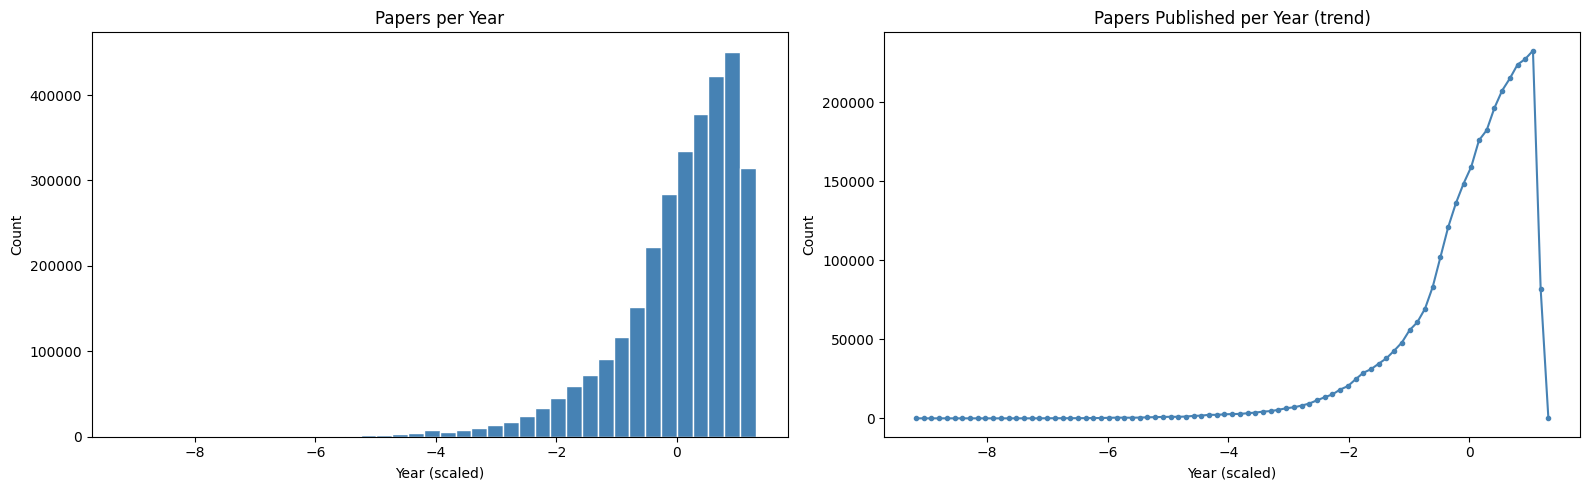

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(combined_df['year'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Papers per Year')
axes[0].set_xlabel('Year (scaled)')
axes[0].set_ylabel('Count')

year_counts = combined_df['year'].value_counts().sort_index()
axes[1].plot(year_counts.index, year_counts.values, marker='o', markersize=3, color='steelblue')
axes[1].set_title('Papers Published per Year (trend)')
axes[1].set_xlabel('Year (scaled)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Citation Count Distribution chart and box plot


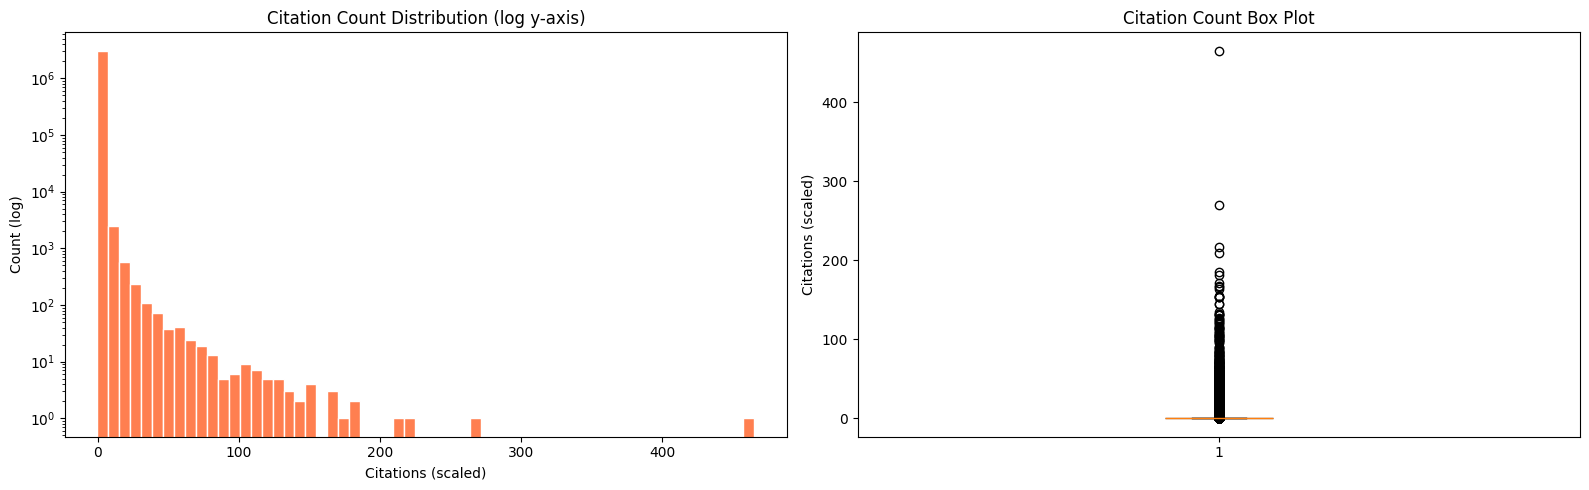

count    3.079007e+06
mean    -0.000000e+00
std      1.000000e+00
min     -2.233000e-01
25%     -2.170000e-01
50%     -1.536000e-01
75%      9.370000e-02
max      4.649746e+02
Name: n_citation, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: Histogram
axes[0].hist(combined_df['n_citation'].dropna(), bins=60, color='coral', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Citation Count Distribution (log y-axis)')
axes[0].set_xlabel('Citations (scaled)')
axes[0].set_ylabel('Count (log)')

# Right plot: Boxplot with log scale to expand the view
axes[1].boxplot(
    combined_df['n_citation'].dropna(),
    vert=True, patch_artist=True,
    boxprops=dict(facecolor='coral', alpha=0.6)
)
axes[1].set_yscale('symlog') # Using symlog to handle zero/negative scaled values
axes[1].set_title('Citation Count Box Plot (Symlog Scale)')
axes[1].set_ylabel('Citations (scaled - log scale)')

plt.tight_layout()
plt.show()

print(combined_df['n_citation'].describe().round(4))

## Authors per Paper bar graph

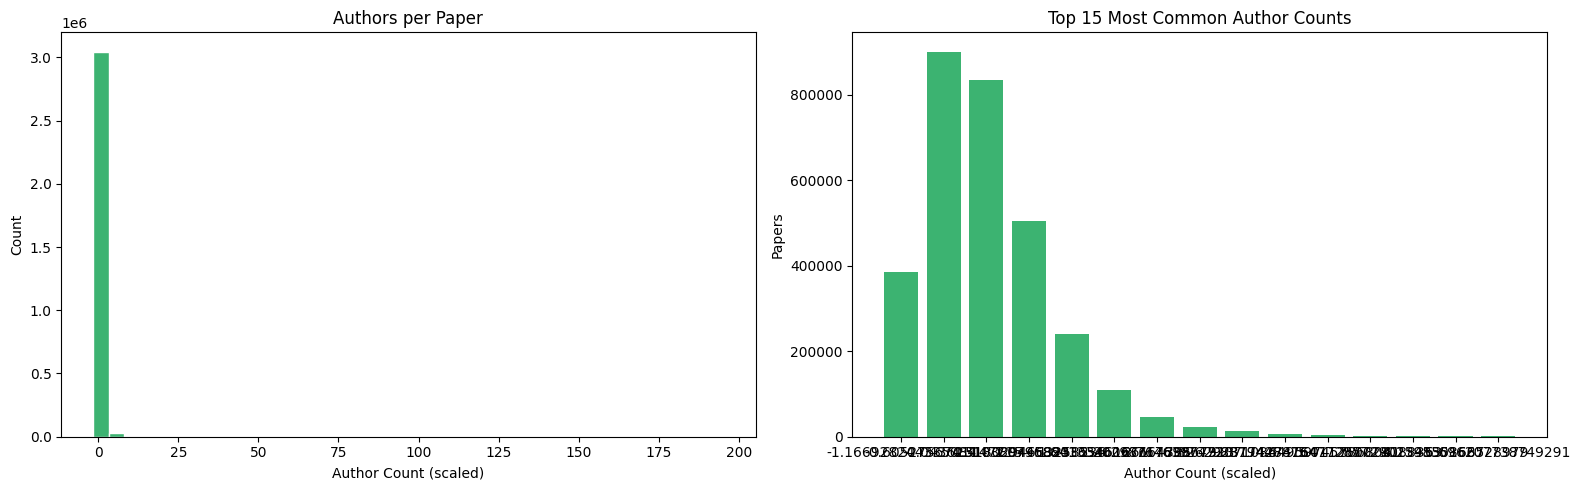

count    3.079007e+06
mean     0.000000e+00
std      1.000000e+00
min     -1.728600e+00
25%     -6.053000e-01
50%     -4.360000e-02
75%      5.180000e-01
max      1.954115e+02
Name: n_authors, dtype: float64


In [ ]:
if 'n_authors' in combined_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(combined_df['n_authors'].dropna(), bins=40, color='mediumseagreen', edgecolor='white')
    axes[0].set_title('Authors per Paper')
    axes[0].set_xlabel('Author Count (scaled)')
    axes[0].set_ylabel('Count')

    top_counts = combined_df['n_authors'].value_counts().head(15).sort_index()
    axes[1].bar(top_counts.index.astype(str), top_counts.values, color='mediumseagreen')
    axes[1].set_title('Top 15 Most Common Author Counts')
    axes[1].set_xlabel('Author Count (scaled)')
    axes[1].set_ylabel('Papers')

    plt.tight_layout()
    plt.show()

    print(combined_df['n_authors'].describe().round(4))
else:
    print('n_authors column not found — skipping.')

## Top Publication Venues

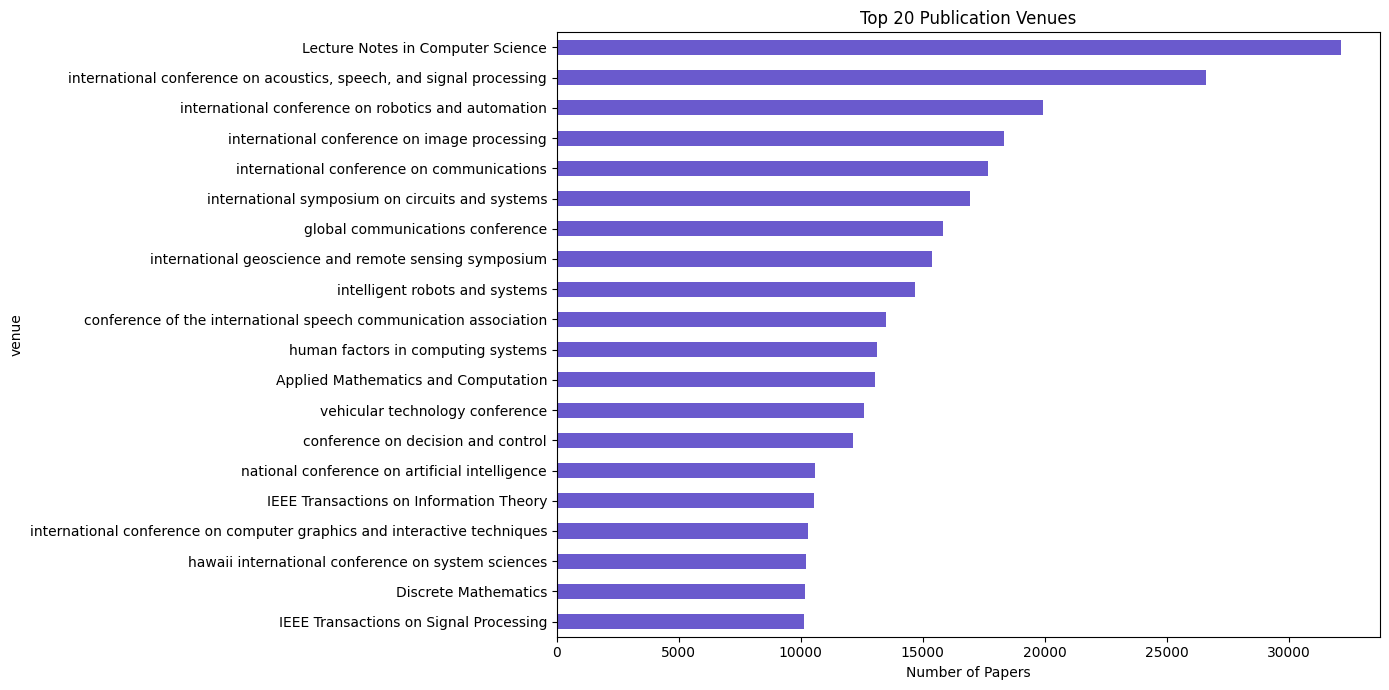

Total unique venues: 1,348
Venues with 1 paper: 1,019


5408

In [ ]:
# --- Memory-efficient: use value_counts on the category column directly ---
venue_counts = (
    combined_df['venue']
    .astype(str)
    .replace('', float('nan'))
    .dropna()
    .value_counts()
)
top_venues = venue_counts.head(20).sort_values()

plt.figure(figsize=(14, 7))
top_venues.plot(kind='barh', color='slateblue')
plt.title('Top 20 Publication Venues')
plt.xlabel('Number of Papers')
plt.tight_layout()
plt.show()

print(f'Total unique venues: {venue_counts.nunique():,}')
print(f'Venues with 1 paper: {(venue_counts == 1).sum():,}')
del venue_counts, top_venues
gc.collect()

##Abstract Length Distribution NOT WORKING

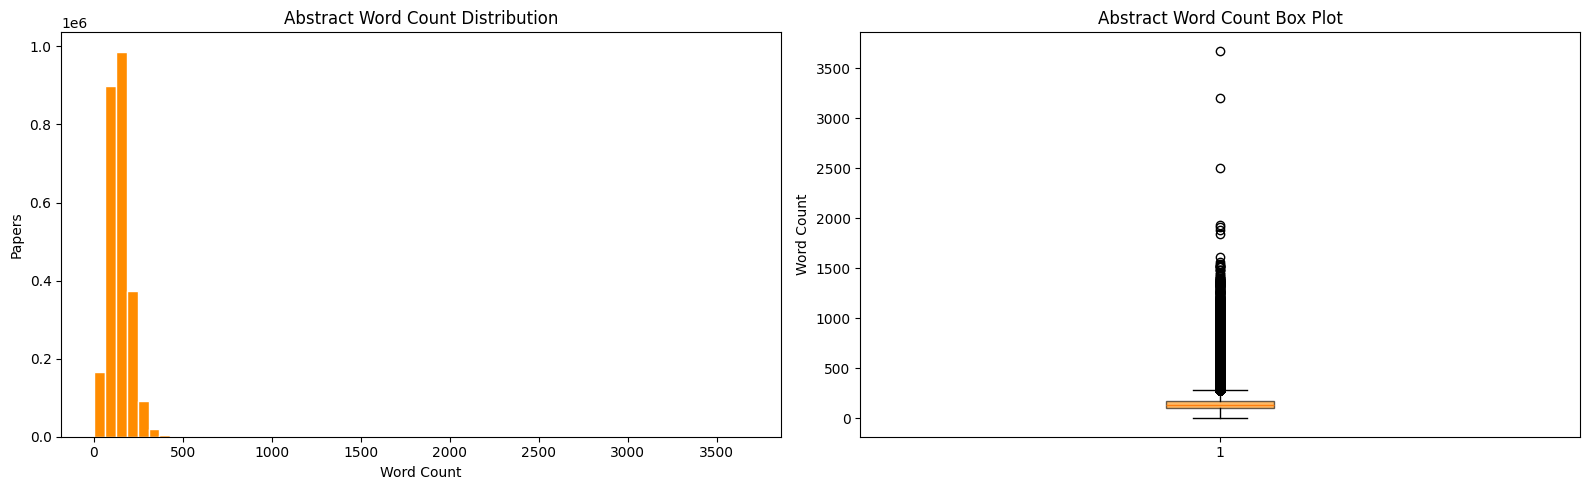

count    2548532.00
mean         140.56
std           61.71
min            1.00
25%          100.00
50%          135.00
75%          172.00
max         3676.00
Name: abstract, dtype: float64
Papers with missing/empty abstracts: 530,475
Papers with abstract: 2,548,532


9501

In [ ]:
import gc

# --- Direct computation of abstract length ---
abstract_lengths = combined_df['abstract'].replace('', float('nan')).dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(abstract_lengths, bins=60, color='darkorange', edgecolor='white')
axes[0].set_title('Abstract Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Papers')

axes[1].boxplot(
    [abstract_lengths],
    patch_artist=True,
    boxprops=dict(facecolor='darkorange', alpha=0.6)
)
axes[1].set_title('Abstract Word Count Box Plot')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print(abstract_lengths.describe().round(2))
print(f'Papers with missing/empty abstracts: {len(combined_df) - len(abstract_lengths):,}')
print(f'Papers with abstract: {len(abstract_lengths):,}')
del abstract_lengths
gc.collect()

## Correlation Between Numeric Features

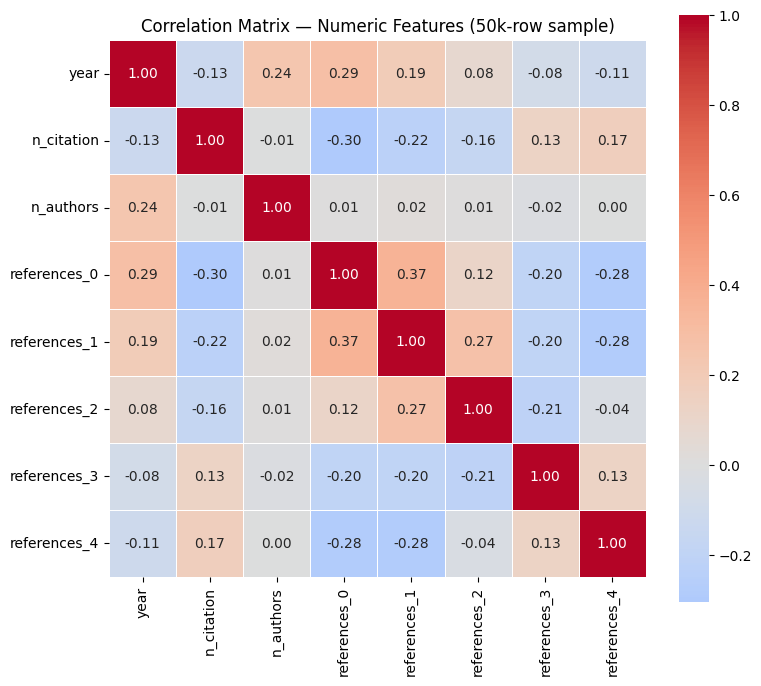

In [ ]:
from sklearn.decomposition import TruncatedSVD
import gc

base_cols = [c for c in ['year', 'n_citation', 'n_authors'] if c in combined_df.columns]
ref_sample_cols = [c for c in combined_df.columns if c.startswith('references_')][:5] # Still take a sample of reference columns if there are many
corr_cols = base_cols + ref_sample_cols

if len(corr_cols) >= 2:
    # Operate on the full DataFrame now, without sampling
    corr_matrix = combined_df[corr_cols].corr()

    plt.figure(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols) - 1)))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='coolwarm', center=0,
        square=True, linewidths=0.5,
    )
    plt.title('Correlation Matrix — Numeric Features (Full Dataset)')
    plt.tight_layout()
    plt.show()
    del corr_matrix
    gc.collect()
else:
    print('Not enough numeric columns for a correlation matrix.')

## Median Citations by Year

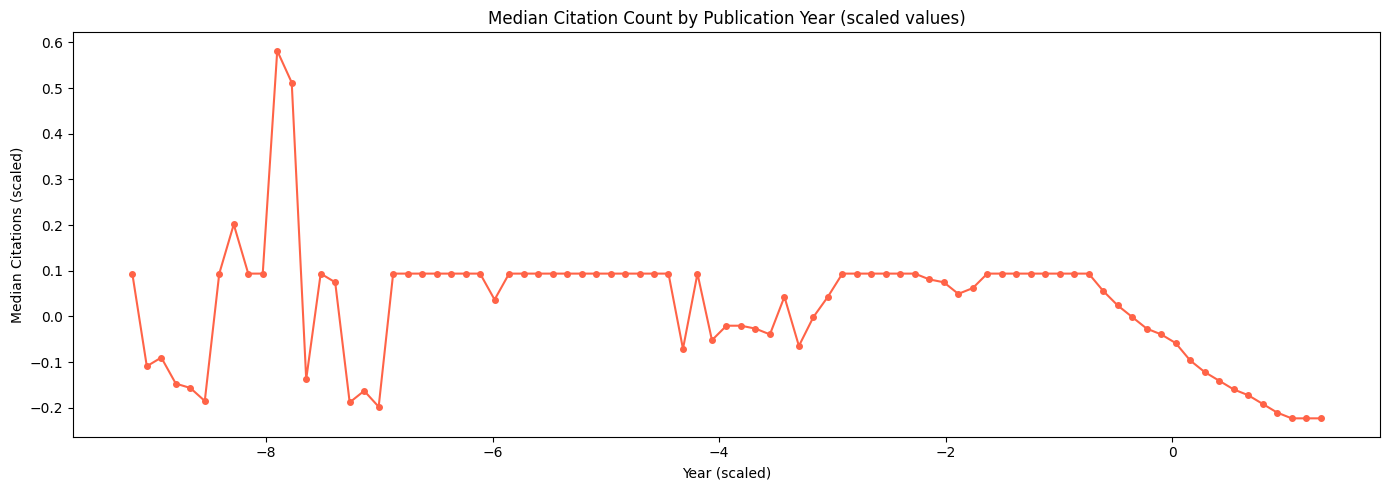

3271

In [ ]:
median_cit_by_year = (
    combined_df.groupby('year')['n_citation']
    .median()
    .reset_index()
    .rename(columns={'n_citation': 'median_citations'})
)

plt.figure(figsize=(14, 5))
plt.plot(
    median_cit_by_year['year'],
    median_cit_by_year['median_citations'],
    marker='o', markersize=4, color='tomato',
)
plt.title('Median Citation Count by Publication Year (scaled values)')
plt.xlabel('Year (scaled)')
plt.ylabel('Median Citations (scaled)')
plt.tight_layout()
plt.show()
del median_cit_by_year
gc.collect()

## 2D TruncatedSVD Scatter of Reference Embeddings
Projects the 20-dim Word2Vec reference embeddings down to 2D. Colored by year.

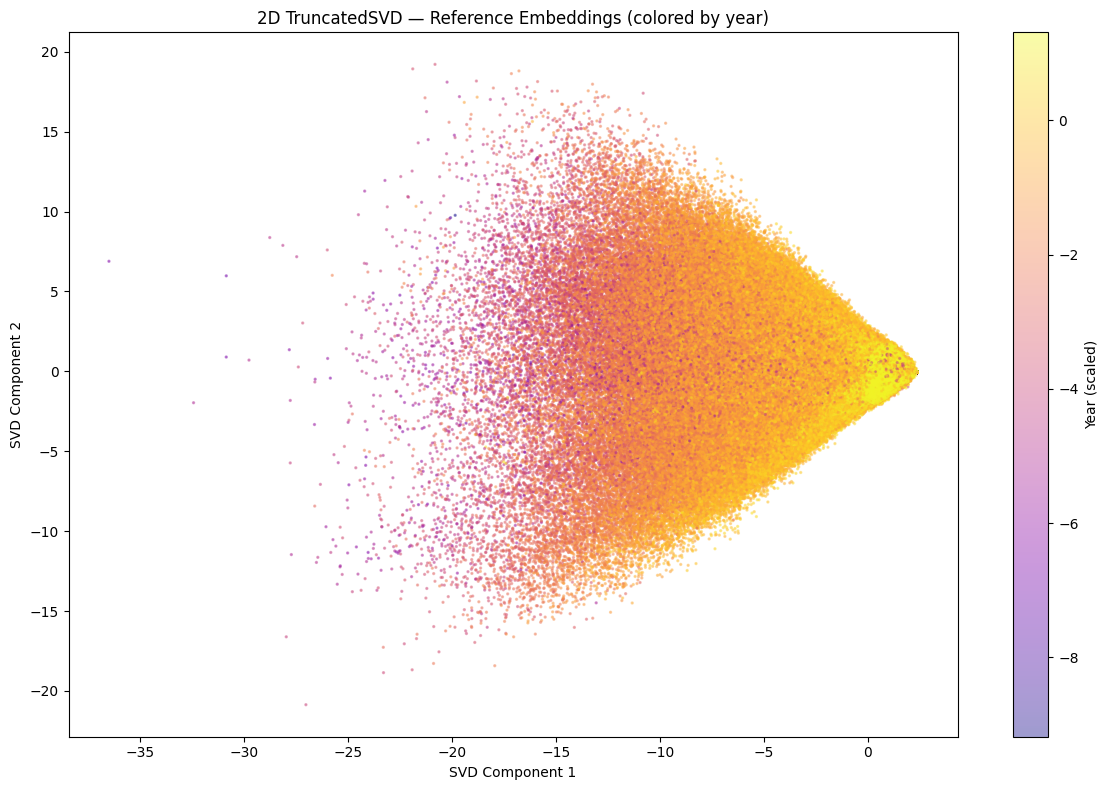

Explained variance ratio: 0.359


In [ ]:
from sklearn.decomposition import TruncatedSVD
import gc

ref_cols_all = [c for c in combined_df.columns if c.startswith('references_')]

if len(ref_cols_all) >= 2:
    X_emb = combined_df.loc[:, ref_cols_all].values.astype('float32')

    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X_emb)
    del X_emb
    gc.collect()

    years = combined_df['year'].fillna(combined_df['year'].median()).values

    plt.figure(figsize=(12, 8))
    sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=years, cmap='plasma', alpha=0.4, s=2)
    plt.colorbar(sc, label='Year (scaled)')
    plt.title('2D TruncatedSVD Reference Embeddings (colored by year)')
    plt.xlabel('SVD Component 1')
    plt.ylabel('SVD Component 2')
    plt.tight_layout()
    plt.show()

    print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}')
    del X_2d, years
    gc.collect()
else:
    print('No reference embedding columns found.')

## EDA Summary



In [ ]:
print('Dataset Summary')
print(f'Total papers      : {len(combined_df):,}')
print(f'Total columns     : {combined_df.shape[1]}')
print(f'Unique venues     : {combined_df["venue"].nunique():,}')

missing_abs = (combined_df['abstract'] == '').sum() + combined_df['abstract'].isna().sum()
print(f'Missing abstracts : {missing_abs:,}  ({100 * missing_abs / len(combined_df):.1f}%)')
print(f'RAM used          : {combined_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

num_cols = combined_df.select_dtypes(include='number').columns.tolist()
print(f'\nNumeric columns   : {num_cols}')
print('\nBasic stats (numeric):')
print(combined_df[num_cols].describe().round(3))

=== Dataset Summary ===
Total papers      : 3,079,007
Total columns     : 30
Unique venues     : 5,079
Missing abstracts : 530,475  (17.2%)
RAM used          : 7940.1 MB

Numeric columns   : ['n_citation', 'year', 'n_authors', 'references_0', 'references_1', 'references_2', 'references_3', 'references_4', 'references_5', 'references_6', 'references_7', 'references_8', 'references_9', 'references_10', 'references_11', 'references_12', 'references_13', 'references_14', 'references_15', 'references_16', 'references_17', 'references_18', 'references_19']

Basic stats (numeric):
        n_citation         year    n_authors  references_0  references_1  \
count  3079007.000  3079007.000  3079007.000   3079007.000   3079007.000   
mean        -0.000        0.000        0.000         0.000        -0.000   
std          1.000        1.000        1.000         1.000         1.000   
min         -0.223       -9.181       -1.729       -19.371       -23.655   
25%         -0.217       -0.482       -

**Reasoning**:
The user wants to identify highly cited papers by calculating the 95th percentile of the 'n_citation' column and filtering the DataFrame accordingly. This involves calculating the threshold, then using it to filter the dataframe, and finally storing the result in a new dataframe.



In [ ]:
import pandas as pd
import joblib
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

SAVEDIR = '/content/drive/MyDrive/dblp-ref/'
DATASET = SAVEDIR + 'dblp_preprocessed.parquet'

# Ensure combined_df is loaded in case of a kernel restart or isolated execution
if 'combined_df' not in locals() and 'combined_df' not in globals():
    combined_df = pd.read_parquet(DATASET)

citation_threshold = combined_df['n_citation'].quantile(0.95)
highly_cited_papers = combined_df[combined_df['n_citation'] >= citation_threshold]

print(f"95th percentile citation threshold: {citation_threshold:.2f}")
print(f"Number of highly cited papers: {len(highly_cited_papers):,}")
print(f"Percentage of highly cited papers: {100 * len(highly_cited_papers) / len(combined_df):.2f}%")

print('\nHighly Cited Papers - Head:')
display(highly_cited_papers.head())

print('\nHighly Cited Papers - Shape:')
print(highly_cited_papers.shape)

print('\nHighly Cited Papers - n_citation descriptive statistics:')
print(highly_cited_papers['n_citation'].describe().round(4))

Mounted at /content/drive
95th percentile citation threshold: 0.36
Number of highly cited papers: 154,513
Percentage of highly cited papers: 5.02%

Highly Cited Papers - Head:


,abstract,authors,n_citation,references,title,venue,year,id,text_combined,n_authors,...,references_10,references_11,references_12,references_13,references_14,references_15,references_16,references_17,references_18,references_19
21,,"[Marco Baroni, Francis Chantree, Adam Kilgarri...",0.417114,[],Cleaneval: a Competition for Cleaning Web Pages.,language resources and evaluation,0.029860,01082175-d4e3-456a-9557-668b2449be05,cleaneval a competition for cleaning web pages...,0.518029,...,0.246319,0.225972,-0.074356,0.333242,-0.085408,0.162746,0.267068,0.019499,0.062685,-0.104939
106,,"[Michael T. Goodrich, Roberto Tamassia]",2.205312,[],Data structures and algorithms in Java (3. ed.),,-0.609810,077f98c2-4f57-4dcc-96ba-2268e26590ad,data structures and algorithms in java 3 ed da...,-0.605276,...,-0.343305,0.026693,-0.453716,-0.604347,0.111151,-0.761960,-0.875499,0.270000,0.099661,0.704079
113,,"[Richard Sproat, Julia Hirschberg, David Yarow...",0.391749,[],A corpus-based synthesizer.,,-2.017082,07e69de2-70f9-4e4c-b1de-fa3a92b63d73,a corpus based synthesizer a corpus based synt...,-0.043623,...,6.104841,7.843449,6.199329,4.275028,-4.192381,5.516965,3.816057,-4.291195,1.614070,-1.588601
157,The Web is evolving from a repository for text...,"[Sheila Mcllraith, Tran Cao Son, Honglei Zeng]",0.518572,"[00fef322-2fb3-403e-9ae5-e69009726677, 40ec5a7...",Mobilizing the semantic web with DAML-enabled ...,international semantic web conference,-0.865677,0a960ce7-3a3a-4c83-bce2-e40b1f69f53e,mobilizing the semantic web with daml enabled ...,-0.043623,...,-2.535200,7.761696,7.281123,-1.651624,-4.756425,2.939283,1.771876,0.672900,0.417582,1.429940
163,The construction of a program that generates c...,"[Matthew L. Ginsberg, Michael Patrick Frank, M...",0.366385,"[8ac3ec28-bc52-4546-9358-867cea3cf992, 90a0951...",Search lessons learned from crossword puzzles,national conference on artificial intelligence,-2.272950,0abff4a0-03b4-4739-b460-aa5313e7c0f1,search lessons learned from crossword puzzles ...,0.518029,...,1.397971,-2.434348,0.781046,2.800327,-4.577428,2.985479,-0.424824,-7.813202,-2.355518,2.567980



Highly Cited Papers - Shape:
(154513, 30)

Highly Cited Papers - n_citation descriptive statistics:
count    154513.0000
mean          1.5661
std           4.1125
min           0.3600
25%           0.5059
50%           0.7722
75%           1.4190
max         464.9746
Name: n_citation, dtype: float64


**Reasoning**:
I need to sample a few highly cited papers and display their titles and abstracts to identify common characteristics. After displaying the sample, I will provide a markdown block summarizing the observations.



In [ ]:
print('\nSample of Highly Cited Papers (Title and Abstract):')
display(highly_cited_papers[['title', 'abstract']].sample(5, random_state=42))



Sample of Highly Cited Papers (Title and Abstract):


,title,abstract
2412666,What is a good digital library? - A quality mo...,"In this article, we elaborate on the meaning o..."
712466,Sharp RIP Bound for Sparse Signal and Low-Rank...,Abstract This paper establishes a sharp cond...
2361844,Haptic discrimination of softness in teleopera...,Many applications in teleoperation and virtual...
390350,Time Optimal Self-Stabilizing Spanning Tree Al...,Thesis (M.S.)--Massachusetts Institute of Tech...
363048,Pipelined cordic architectures for fast VLSI f...,The paper presents a revised functional descri...
